In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
train = pd.read_csv('../train.csv', parse_dates=['Date'])
test = pd.read_csv('../test.csv', parse_dates=['Date'])
features = pd.read_csv('../features.csv', parse_dates=['Date'])
stores = pd.read_csv('../stores.csv')

train.shape, test.shape, features.shape, stores.shape

((421570, 5), (115064, 4), (8190, 12), (45, 3))

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


In [5]:
print(train['Date'].min(), train['Date'].max())
print(test['Date'].min(), test['Date'].max())
print(train['Store'].nunique(), train['Dept'].nunique())

2010-02-05 00:00:00 2012-10-26 00:00:00
2012-11-02 00:00:00 2013-07-26 00:00:00
45 81


In [6]:
df = train.merge(stores, on='Store', how='left')
df = df.merge(features.drop(columns=['IsHoliday']), on=['Store', 'Date'], how='left')
df.shape

(421570, 16)

In [7]:
df.isna().mean().sort_values(ascending=False)

MarkDown2       0.736110
MarkDown4       0.679847
MarkDown3       0.674808
MarkDown1       0.642572
MarkDown5       0.640790
Store           0.000000
Date            0.000000
Dept            0.000000
Temperature     0.000000
Size            0.000000
Type            0.000000
IsHoliday       0.000000
Weekly_Sales    0.000000
Fuel_Price      0.000000
CPI             0.000000
Unemployment    0.000000
dtype: float64

In [8]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df.groupby(df['Date'].dt.year)[markdown_cols].apply(lambda x: x.isna().mean())

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Date,,,,,
2010,1.000000,1.000000,1.000000,1.000000,1.000000
2011,0.845555,0.868663,0.849361,0.862877,0.843639
2012,0.003586,0.285190,0.105644,0.106036,0.000000


In [9]:
df['Weekly_Sales'].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [10]:
(df['Weekly_Sales'] < 0).sum(), (df['Weekly_Sales'] == 0).sum()

(np.int64(1285), np.int64(73))

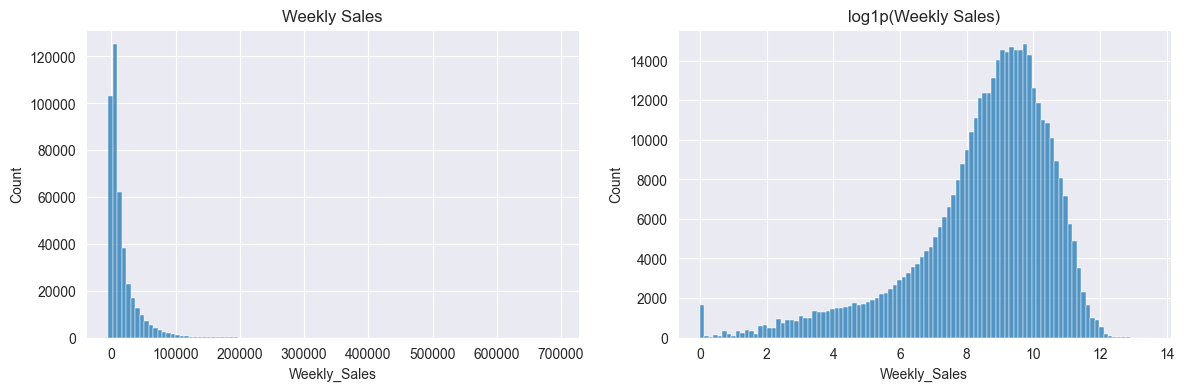

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Weekly_Sales'], bins=100, ax=ax[0])
sns.histplot(np.log1p(df['Weekly_Sales'].clip(lower=0)), bins=100, ax=ax[1])
ax[0].set_title('Weekly Sales')
ax[1].set_title('log1p(Weekly Sales)')
plt.show()

In [12]:
df.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'count'])

,mean,median,count
IsHoliday,,,
False,15901.445069,7589.95,391909
True,17035.823187,7947.74,29661


In [13]:
holidays = {
    'Super Bowl': ['2010-02-12', '2011-02-11', '2012-02-10'],
    'Labor Day': ['2010-09-10', '2011-09-09', '2012-09-07'],
    'Thanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23'],
    'Christmas': ['2010-12-31', '2011-12-30', '2012-12-28'],
}

for name, dates in holidays.items():
    mask = df['Date'].isin(pd.to_datetime(dates))
    print(name, df.loc[mask, 'Weekly_Sales'].mean())

Super Bowl 16377.996440697021
Labor Day 15881.693339352218
Thanksgiving 22220.944537674106
Christmas 14543.38715775311


In [14]:
df.groupby('Date')['Weekly_Sales'].sum()['2010-11-19':'2011-01-14']

Date
2010-11-19    45125584.18
2010-11-26    65821003.24
2010-12-03    49909027.88
2010-12-10    55666770.39
2010-12-17    61820799.85
2010-12-24    80931415.60
2010-12-31    40432519.00
2011-01-07    42775787.77
2011-01-14    40673678.04
Name: Weekly_Sales, dtype: float64

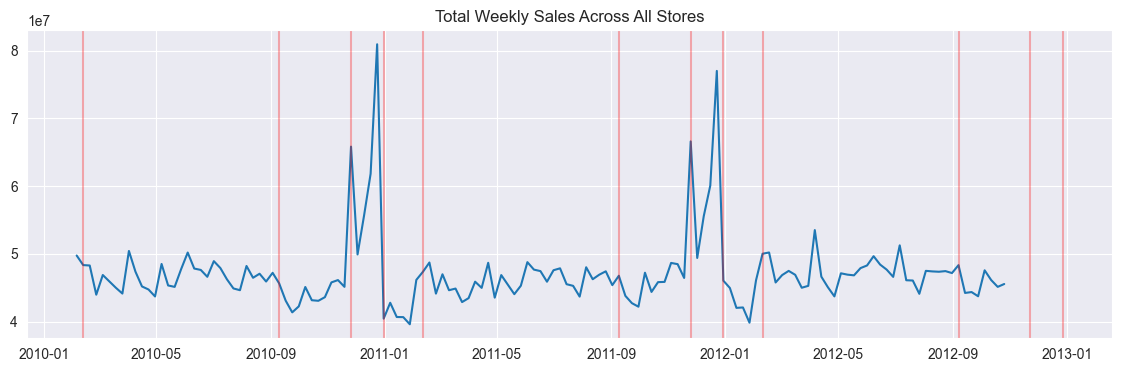

In [15]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14, 4))
plt.plot(weekly_total.index, weekly_total.values)
for dates in holidays.values():
    for d in pd.to_datetime(dates):
        plt.axvline(d, color='red', alpha=0.3)
plt.title('Total Weekly Sales Across All Stores')
plt.show()

In [16]:
stores['Type'].value_counts()

Type
A    22
B    17
C     6
Name: count, dtype: int64

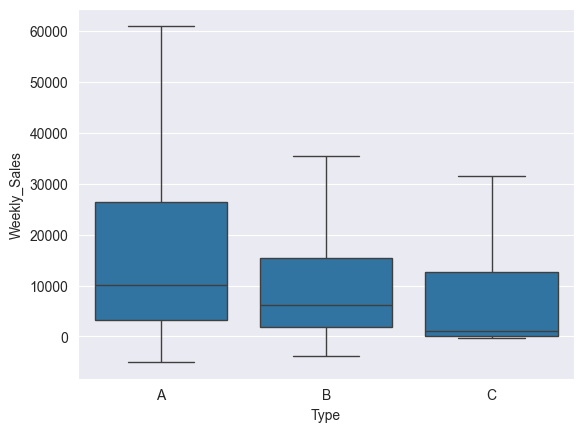

In [17]:
sns.boxplot(data=df, x='Type', y='Weekly_Sales', order=['A', 'B', 'C'], showfliers=False)
plt.show()

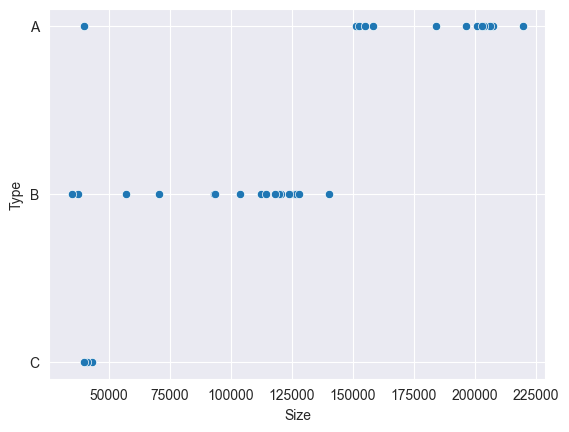

In [18]:
sns.scatterplot(data=stores, x='Size', y='Type')
plt.show()

In [19]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
dept_sales.head(10)

Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
90    45232.084488
40    44900.702727
2     43607.020113
91    33687.910758
94    33405.883963
Name: Weekly_Sales, dtype: float64

In [20]:
dept_sales.tail(10)

Dept
99    415.487065
60    347.370229
77    328.961800
54    108.305985
45     23.211586
51     21.931729
39     11.123750
78      7.296638
43      1.193333
47     -7.682554
Name: Weekly_Sales, dtype: float64

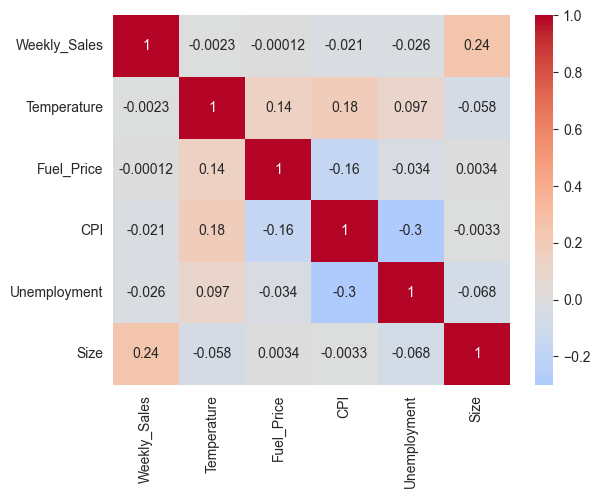

In [21]:
num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [22]:
train_pairs = set(zip(train['Store'], train['Dept']))
test_pairs = set(zip(test['Store'], test['Dept']))
len(test_pairs - train_pairs)

11